In [371]:
import pandas as pd
import sympy as sp
import matplotlib.ticker as ticker
from scipy.optimize import curve_fit
from matplotlib.ticker import FormatStrFormatter
from matplotlib.gridspec import GridSpec
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath,amssymb}'
import math
from scipy.optimize import root_scalar
from scipy.optimize import minimize_scalar
from scipy.optimize import brentq
from scipy.interpolate import interp1d
import heapq
pi=math.pi


**Equations of motion for static spherical boson star**

A static spherical boson star can be described by a metric of the form

$$
ds^2 = - \alpha\left( R \right)^2 dt^2 + a\left( R \right)^2 dR^2 + R^2 d\Omega^2
$$

in the usual Schwarzschild coordinates, or by

$$
ds^2 = - \alpha\left( r \right)^2 dt^2 + \Phi\left( r \right)^4 \left( dr^2 + r^2 d\Omega^2 \right)
$$

in isotropic coordinates. The stress energy tensor is sourced by a complex scalar field

$$
T_{\mu \nu} = \partial_{(\mu} \bar{\varphi} \partial_{\nu)} \varphi 
  - \frac{1}{2} g_{\mu \nu} \left( \partial^\alpha \bar{\varphi} \partial_\alpha \varphi + V \right)
$$

where we use the ansatz

$$
\varphi = A\left( r \right) e^{i \omega t}.
$$

Einstein's equations yield three nontrivial equations determining the radial profiles of $\alpha, a / \Phi,$ and $A$. Below we define the system of equations in both coordinate systems. 

In [372]:

# Define the Einstein-Klein-Gordon equations for a single stationary boson star in schwarzschild coordinates
def odes_schwz(r, Y, omega, mu):

    #Independent variables
    a, alpha, A, eta, f = Y  
    
    #Potential
    #sigma=0.14
    V = (mu*A)**2 #*(1-(A/sigma)**2)**2
    V_prime = mu**2 #*((1-2*(A/sigma)**2)**2) + (-4/sigma*2)*(mu*A)**2*(1-(A/sigma)**2)

    #Equations of motion
    dadr = 1/2 * ( 4*pi*a*r * (a**2*V + (omega/alpha*a*A)**2 + eta**2))
    dalphadr = alpha/2 * (4*pi*r * ((omega/alpha*a*A)**2 - a**2*V + eta**2))
    dAdr =  eta
    detadr = (V_prime - (omega/alpha)**2) * a**2 * A 

    if r==0:
        dadr = 0
        dalphadr = 0
        detadr = detadr - (V_prime - (omega/alpha)**2) * a**2 * ( A - 1/(3+a**2))
        dfdr = 0
    else:
        dadr = dadr + 1/2 * a/r * (1 - a**2)
        dalphadr = dalphadr + alpha/2 * 1/r * (a**2 - 1)
        detadr = detadr - (1 + a**2 - 4*pi*r**2*a**2*V) * eta/r
        dfdr = f/r*(a-1)
    
    return [dadr, dalphadr, dAdr, detadr, dfdr] 

# Define the Einstein-Klein-Gordon equations for a single stationary boson star in isotropic coordinates
def odes_iso(r, Y, omega, mu):

    #Independent variables
    Phi, Pi, Theta, Psi, A, eta = Y

    #Potential
    #mu=4.06
    #sigma=0.14
    V = 0.5*(mu*A)**2 #*(1-(A/sigma)**2)**2
    V_prime = mu**2 #*((1-2*(A/sigma)**2)**2) + (-4/sigma*2)*(mu*A)**2*(1-(A/sigma)**2)

    #\rho_H and S = \gamma^{ij} S_{ij}
    rho_H = 1/2 * ( (Phi/Theta*omega*A)**2 + eta**2/Phi**4 + 2*V ) 
    S = -1/2 * ( eta**2/Phi**4 + 3*( -(Phi/Theta*omega*A)**2 + 2*V ) )

    #Equations of motion
    dPhidr = Pi
    dPidr = -2*pi*Phi**5 * rho_H 
    dThetadr = Psi
    dPsidr = 2*pi*Theta*Phi**4 * (rho_H + 2*S) 
    dAdr = eta
    detadr = - ( Psi/Theta + Pi/Phi ) * eta + (V_prime - (Phi/Theta*omega)**2 ) * Phi**4 * A 

    if r==0:
        dPidr = dPidr + 4/3*pi*Phi**5 * rho_H
        dPsidr = dPsidr - 4/3*pi*Theta*Phi**4 * (rho_H+2*S)
        detadr = detadr - 2/3 * ( - ( Psi/Theta + Pi/Phi ) * eta + (V_prime - (Phi/Theta*omega)**2 ) * Phi**4*A)
    else:
        dPidr = dPidr - 2*Pi/r
        dPsidr = dPsidr - 2*Psi/r
        detadr = detadr - 2*eta/r
    
    return [dPhidr, dPidr, dThetadr, dPsidr, dAdr, detadr]


#Newton rapshon solver just in case
def newton_raphson(x0, tol, max_iter):
    x = x0
    gam = 1/np.sqrt(1-x**2)
    for i in range(max_iter):
        
        gam = 1/np.sqrt(1-x**2)
        lam = (1/gam - 1)/x**2

        f = M[-1]*(gam**2+lam)*x + N[-1]*gam**2*(x+lam*x**3) - P
        

        dx = 1
        dgam = gam**3*x
        dlam = -dgam/(gam*x)**2 - 2/x*lam
        df = ( M[-1]*(2*gam*dgam*x + gam**2*dx + dlam*x+lam*dx) 
              + N[-1]*(2*gam*dgam*(x+lam*x**3)+gam**2*(dx+dlam*x**3+3*lam*x**2*dx)))

        # Check convergence
        if abs(f) < tol:
            return x, i

        # Avoid division by zero
        if df == 0.0:
            print("Derivative is zero. Method fails.")
            return None, i

        # Newton update
        x = x - f / df

    print("Did not converge within max_iter.")
    return x, max_iter

**Numerical integration**

Static configurations of any spherically symmetric spacetime must be Schwarzschild, so any solutions to the above coupled system of equations must satisfy:

$$
\alpha \left( \infty \right) \approx 1 - \frac{2M}{r} \\
a \left( \infty \right) \approx \left( 1 - \frac{2M}{r} \right)^{-1}  \\
A \left( \infty \right) \approx C \frac{1}{r} e^{-\sqrt{\mu-\omega^2}r}
$$

To numerically integrate the equations of motion, we specify the following initial conditions at the origin and integrate outward to a fixed radius. In Schwarzschild coordinates, we have

$$
\alpha \left( 0 \right) = 1 \\
a \left( 0 \right) = 1 \\
A \left( 0 \right) = A_0 \\
A' \left( 0 \right) = 0
$$

while in isotropic coordinates we have

$$
\left(\alpha \Phi \right) \left( 0 \right) = 1 \\
\left(\alpha \Phi \right)' \left( 0 \right) = 0 \\
\Phi \left( 0 \right) = 1 \\
\Phi' \left( 0 \right) = 0 \\
A \left( 0 \right) = A_0 \\
A' \left( 0 \right) = 0
$$

One then varies $\omega$ until a solution is found that satisfies the asympototic behavior of the scalar field. In practice, one finds the best solution by minimizing the following residual function with respect to $\omega$, 

$$
\epsilon = \sum_{i=\text{max}-n}^\text{max}  \left[ A(r_i) - \frac{C}{r_i}\,\exp \left(-\sqrt{\mu^2 - \omega^2/\alpha^2(r_i)}\,r_i\right) \right]
$$

where

$$
C = A(r_{\text{max}})\,r_{\text{max}}\,\exp \left(\sqrt{\mu^2 - \omega^2/\alpha^2(r_{\text{max}})}\,r_i\right)
$$

In [373]:
# Define a function to solve odes_schwz via RK45 given central amplitude of scalar field 'A0' and frequency guess 'omega'
def solve_bs_schwz_rk45(A0, omega, r_max, num_points, mu):
    r_min = 0
    r_span = (r_min, r_max)
    
    y0 = [1, 1, A0, 0, 1]  # a, alpha, A, eta
    r_eval = np.linspace(r_min, r_max, num_points)
    
    sol = solve_ivp(odes_schwz, r_span, y0, args=(omega,mu), t_eval=r_eval, method='RK45', rtol=1e-12, atol=1e-15)
    return sol

# Define a function to solve odes_iso via RK45 given central amplitude of scalar field 'A0' and frequency guess 'omega'
def solve_bs_iso_rk45(A0, omega, r_max, num_points, mu):
    r_min = 0
    r_span = (r_min, r_max)
    
    y0 = [1, 0, 1, 0, A0, 0]  # Phi, Pi, Theta, Psi, A, eta
    r_eval = np.linspace(r_min, r_max, num_points)
    
    sol = solve_ivp(odes_iso, r_span, y0, args=(omega,mu), t_eval=r_eval, method='RK45', rtol=1e-12, atol=1e-12)
    return sol

# Define a function to solve odes_iso via RK4 given central amplitude of scalar field 'A0' and frequency guess 'omega'
def solve_bs_iso_rk4(A0, omega, r_max, num_points, mu):

    h = r_max/(num_points-1)
    def rk4step(odes_iso, r, Y, h, omega, mu):
        k1 = np.array(odes_iso(r, Y, omega, mu))
        k2 = np.array(odes_iso(r+h/2, Y+h/2*k1, omega, mu))    
        k3 = np.array(odes_iso(r+h/2, Y+h/2*k2, omega, mu))
        k4 = np.array(odes_iso(r+h, Y+h*k3, omega, mu))
        return Y + h/6*(k1 + 2*k2 + 2*k3 +k4)
    
    Y = np.array([1, 0, 1, 0, A0, 0], dtype=float)
    sol = np.zeros((len(Y), num_points))
    for i in range(num_points):
        sol[:,i] = Y
        Y = rk4step(odes_iso, h*i, Y, h, omega, mu)
    return sol
    

#Define a function to return epsilon given a central amplitude and frequency in schwarzschild coordinates
def objective_schwz(omega, A0, r_max, num_points, mu):
    sol2 = solve_bs_schwz_rk45(A0, omega, r_max, num_points, mu)

    npts = 30
    alp = sol2.y[1][-1]
    k=np.sqrt(mu**2-omega**2/alp**2)
    C = sol2.y[2][-1]*sol2.t[-1]*np.exp(k*sol2.t[-1])

    numerator = 0
    for i in range(npts):
        numerator = numerator + (sol2.y[2][-1-i] - C/sol2.t[-1-i]*np.exp(-k*sol2.t[-1-i]))

    epsilon = numerator
    return epsilon

#Define a function to return epsilon given a central amplitude and frequency in isotropic coordinates
def objective_iso(omega, A0, r_max, num_points, mu):
    sol2 = solve_bs_iso_rk45(A0, omega, r_max, num_points, mu)

    npts = 30
    alp = sol2.y[2]/sol2.y[0]
    k=np.sqrt(mu**2-omega**2/alp**2)
    C = sol2.y[4][-1]*sol2.t[-1]*np.exp(k[-1]*sol2.t[-1])

    numerator = 0
    for i in range(npts):
        numerator = numerator + (sol2.y[4][-1-i] - C/sol2.t[-1-i]*np.exp(-k[-1-i]*sol2.t[-1-i]))
    
    epsilon = numerator
    return epsilon

#Define a function to return epsilon given a central amplitude and frequency in isotropic coordinates
def objective_iso_rk4(omega, A0, r_max, num_points, mu):
    sol2 = solve_bs_iso_rk4(A0, omega, r_max, num_points, mu)
    
    r = np.linspace(0, r_max, num_points)
    npts = 30
    alp = sol2[2]/sol2[0]
    arg = mu**2 - omega**2 / alp[-1]**2
    k = np.sqrt(arg)
    C = sol2[4][-1]*r[-1]*np.exp(k*r[-1])

    numerator = 0
    #denominator = 0
    for i in range(npts):
        arg = mu**2 - omega**2 / alp[-1]**2
        k = np.sqrt(arg)
        numerator = numerator + (sol2[4][-1-i] - C/r[-1-i]*np.exp(-k*r[-1-i]))
        #denominator = denominator + (1/sol2.t[-1-i]*np.exp(-k*sol2.t[-1-i]))**2
    
    epsilon = numerator
    return epsilon

**Parameters**

We first consider the potential

$$
V = \mu \varphi \bar{\varphi}
$$

and set $\mu=1$ which essentially makes our units dimensionless. One also has to decide the maximum radius to integrate to and the number of points. The numerical integration is VERY sensitive to the maximum radius you choose.

In [374]:
#parameter in potential and scalar field amplitude
mu=1
A0 = 0.05

#integration parameters
r_max = 20/mu
num_points = 4000

def load_boson_star_params():
    """
    Parameters for A0 = 0.01
        r_max = 70
        num_points = 4000
        omega = 1.02394494597923114 / 0.9762195182802345
        M_adm = 3.60935363e-01
        R/r = 24.996249062265566 / 24.634363184701837
        asymptotic_phi = 7.397139109625441e-08

    Parameters for A0 = 0.02
        r_max = 60
        num_points = 4000
        omega = 1.04984409430713788 / 0.9539102940592108
        M_adm = 4.75143311e-01
        R/r = 17.254313578394598 / 16.77631551563905
        asymptotic_phi = 1.3365992991262099e-08

    Parameters for A0 = 0.03
        r_max = 50
        num_points = 4000
        omega = 1.07788555200562541 / 0.9330107069237683
        M_adm = 5.42374015e-01
        R/r = 13.77844461115279 / 13.231112652533245
        asymptotic_phi = 2.4642339237933737e-08

    Parameters for A0 = 0.04
        r_max = 45
        num_points = 4000
        omega = 1.10828046081659304 / 0.9134675212346415
        M_adm = 5.84390056e-01
        R/r = 11.669167291822955 / 11.077743074452838 
        asymptotic_phi = 3.031192517384311e-08 

    Parameters for A0 = 0.05
        r_max = 40
        num_points = 4000
        omega = 1.14126635566277779 / 0.8952353496964208
        M_adm = 6.10318859e-01
        R/r = 10.222555638909727 / 9.603266620464176
        
        asymptotic_phi = 6.755241841611666e-08
    """
    pass


**Plotting the residual function**

We need to narrow down the range where the eigenfrequency is. 

In [ ]:
omegas = np.linspace(1*mu, 1.15*mu, 200)
residuals = [objective_schwz(omega, A0, r_max, num_points, mu) for omega in omegas];

plt.plot(omegas, residuals, 'o-')
#plt.axhline(0, color='k', linestyle='--')
plt.xlabel('omega')
plt.ylabel('residual')
plt.title('Residual vs omega')
plt.grid()
plt.show()

**Plotting the residual function**

This block iteratively refines the frequency range, discarding numerically unstable frequencies and zooming in on the correct region of the residual function landscape.

/var/folders/18/tntv6zhx4157ggv61jp7lxq00000gn/T/ipykernel_32960/910680509.py:44: RuntimeWarning: overflow encountered in scalar power
  rho_H = 1/2 * ( (Phi/Theta*omega*A)**2 + eta**2/Phi**4 + 2*V )
/var/folders/18/tntv6zhx4157ggv61jp7lxq00000gn/T/ipykernel_32960/910680509.py:45: RuntimeWarning: overflow encountered in scalar power
  S = -1/2 * ( eta**2/Phi**4 + 3*( -(Phi/Theta*omega*A)**2 + 2*V ) )
/var/folders/18/tntv6zhx4157ggv61jp7lxq00000gn/T/ipykernel_32960/910680509.py:49: RuntimeWarning: overflow encountered in scalar power
  dPidr = -2*pi*Phi**5 * rho_H
/var/folders/18/tntv6zhx4157ggv61jp7lxq00000gn/T/ipykernel_32960/910680509.py:51: RuntimeWarning: overflow encountered in scalar power
  dPsidr = 2*pi*Theta*Phi**4 * (rho_H + 2*S)
/var/folders/18/tntv6zhx4157ggv61jp7lxq00000gn/T/ipykernel_32960/910680509.py:53: RuntimeWarning: overflow encountered in scalar power
  detadr = - ( Psi/Theta + Pi/Phi ) * eta + (V_prime - (Phi/Theta*omega)**2 ) * Phi**4 * A
/var/folders/18/tntv6zhx

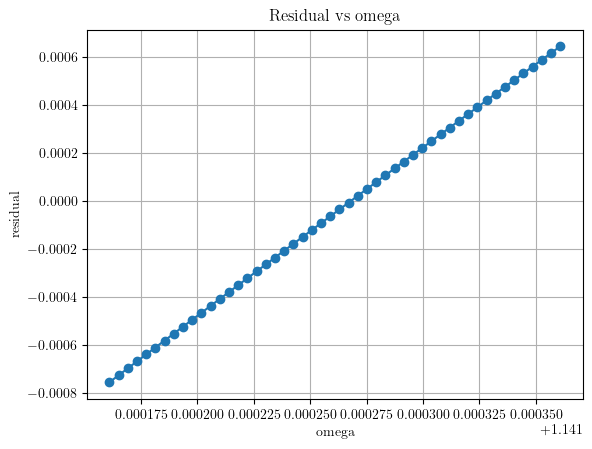

In [378]:
omegas = np.linspace(1*mu, 1.15*mu, 200)
residuals = np.array([objective_iso_rk4(omega, A0, r_max, num_points, mu) for omega in omegas])
#print(omegas)

for i in range(2):
    mask = np.isfinite(residuals)  # keeps only non-NaN and finite values

    omegas_clean = omegas[mask]
    residuals_clean = residuals[mask]
    omega_min = omegas_clean[np.argmin(np.abs(residuals_clean))]
    omegas = np.linspace(omega_min - 0.001/10**i, omega_min + 0.001/10**i)
    residuals = np.array([objective_iso_rk4(omega, A0, r_max, num_points, mu) for omega in omegas])

plt.plot(omegas, residuals, 'o-')
#plt.axhline(0, color='k', linestyle='--')
plt.xlabel('omega')
plt.ylabel('residual')
plt.title('Residual vs omega')
plt.grid()
plt.show()

**Minimizing the residual function**

Now that we've narrowed down the interval with the true minimum, we can properly minimize the residual.

In [379]:
def bisection(f, A0, omega_min, omega_max, r_max, num_points, mu, tol=1e-15, max_iter=1000):
    """
    Simple bisection method to find root of f(omega, A0) = 0
    """
    a, b = omega_min, omega_max
    fa, fb = f(a, A0, r_max, num_points, mu), f(b, A0, r_max, num_points, mu)
    
    if fa * fb > 0:
        raise ValueError("Function does not change sign in the interval. Bisection cannot proceed.")
    
    for i in range(max_iter):
        c = (a + b) / 2
        fc = f(c, A0, r_max, num_points, mu)
        
        # Check if we are close enough
        if abs(fc) < tol or (b - a)/2 < tol:
            return c, fc
        
        # Decide which subinterval to keep
        if fa * fc < 0:
            b, fb = c, fc
        else:
            a, fa = c, fc
    
    # Max iterations reached
    return (a + b) / 2, f((a + b)/2, A0, r_max, num_points)

# Example usage:
omega_root, fval = bisection(objective_iso_rk4, A0, omegas[0], omegas[-1], r_max, num_points, mu)
print(f"Root omega: {omega_root:.17f}")
print(f"Function value at root: {fval:.17e}")



Root omega: 1.14126807770691130
Function value at root: -6.28728839824344021e-16


**Solution in Scwharzschild coordinates**

One may have noticed that we set 

$$
\alpha \left( 0 \right) = 1. 
$$

This was purely for convenience. Because of the structure of the equations of motion, one can simultaneously rescale $\alpha$ and $\omega$ to achieve appropriate boundary conditions while changing nothing.

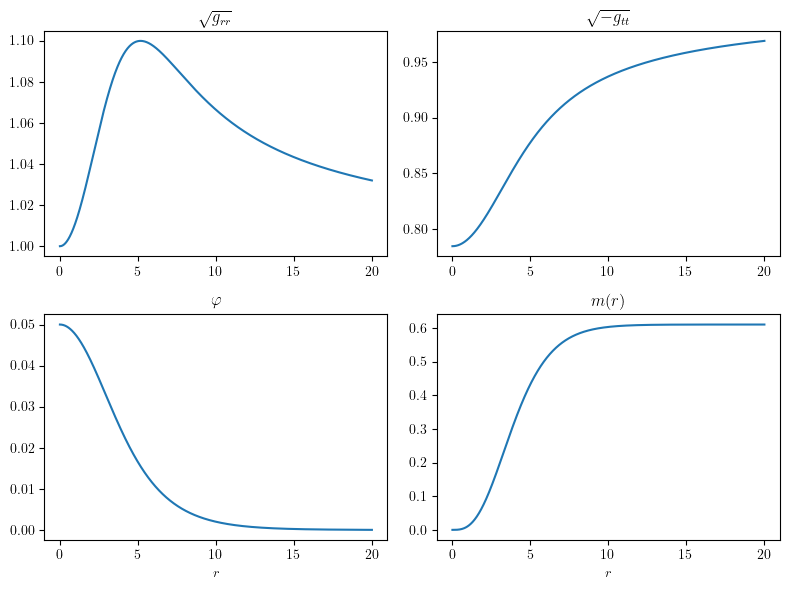

First crossing at index 2042
10.212553138284571
0.6102337947894998


In [380]:
sol = solve_bs_schwz_rk45(A0, 1.14126807770691130, r_max, num_points, mu)

#Rescaling alpha and omega
c = 1/sol.y[0][-1]/sol.y[1][-1]
sol.y[1] = c*sol.y[1]
eigen_schwz = 1.14126807770691130*c

#mass function
m = -sol.t/2*(1/sol.y[0]**2-1)

#Plot results
fig, axes = plt.subplots(2, 2, figsize=(8, 6))  # 2 rows, 2 columns

solution_schwz = [sol.y[0], sol.y[1], sol.y[2], m]  # replace with your 4 matrices
labels = [r"$\sqrt{g_{rr}}$", r"$\sqrt{-g_{tt}}$", r"$\varphi$", r"$m(r)$"]

for i, (ax, solution, label) in enumerate(zip(axes.flatten(), solution_schwz, labels)):
    ax.plot(sol.t, solution)
    ax.set_title(label)
    if i >= 2:
        ax.set_xlabel(r"$r$")

plt.tight_layout()
plt.show()

adm = m[-1]

#compute areal radius at which 99% of adm mass is enclosed
mask = m / m[-1] > 0.99
if np.any(mask):
    i = np.argmax(mask)
    print("First crossing at index", i)
    rad = i
    
print(sol.t[rad])

print(m[-1])

**Conformal factor**

One can solve for the conformal factor while integrating the solution in Schwarzschild coordinates, from
 
$$
\psi = \frac{R^2}{r^2}
$$

and

$$
\frac{d}{dR}\left( \frac{r}{R} \right) = \frac{1}{R} \left( \frac{r}{R} \right) \left(a - 1 \right)
$$

10.232261267667614


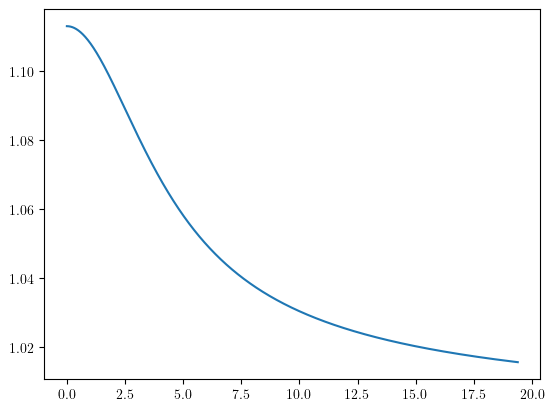

In [381]:
confac = np.sqrt(1/sol.y[4])

#rescale appropriately
scale = ( confac[-1] - np.sqrt(confac[-1]**2 - 2*m[-1]/sol.y[4][-1]/sol.t[-1]) )/ (m[-1]/sol.y[4][-1]/sol.t[-1])
confac = scale*confac
sol.y[4] = sol.y[4]/scale**2

plt.plot(sol.t*sol.y[4], confac)

#isotropic radius containing 99% of adm mass
isotropic = areal/confac[rad]**2
print(isotropic)

**Solution in Isotropic coordinates (RK45)**

One may have noticed that we set 

$$
\alpha \left( 0 \right) = 1\,, \\
\psi \left( 0 \right) = 1\,. 
$$

This was purely for convenience. Because of the structure of the equations of motion, one can simultaneously rescale $\alpha$ and $\omega$, and $\psi$ and $r$ to achieve appropriate boundary conditions while changing nothing.

/var/folders/18/tntv6zhx4157ggv61jp7lxq00000gn/T/ipykernel_32960/408757175.py:27: RuntimeWarning: invalid value encountered in divide
  ax.plot(sol2.t, (1+m/2/sol2.t))


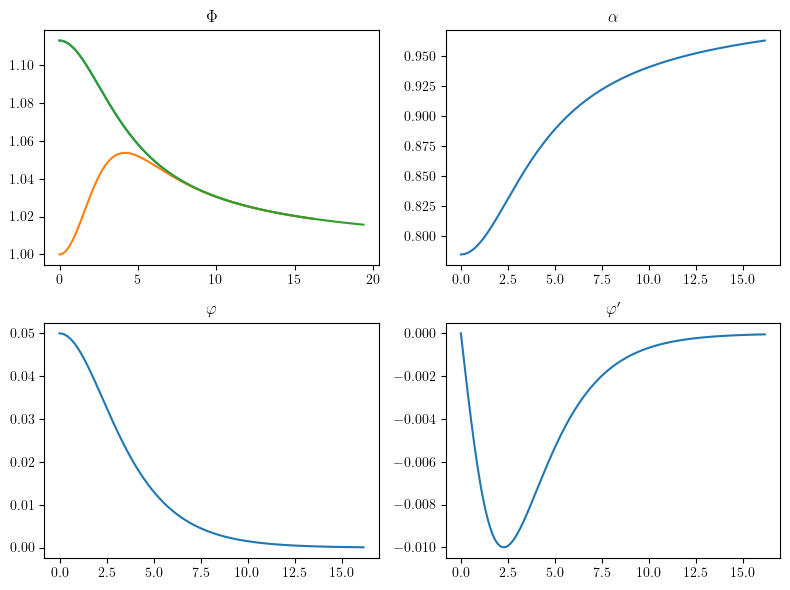

In [383]:
sol2 = solve_bs_iso_rk45(A0,  1.14126807770691130, r_max, num_points, mu)
psi_rescale_factor = sol2.y[0][-1] + sol2.t[-1]*sol2.y[1][-1]
theta_rescale_factor = sol2.y[2][-1] + sol2.t[-1]*sol2.y[3][-1]

eigen_iso =  1.14126807770691130/theta_rescale_factor*psi_rescale_factor

sol2.y[0] = sol2.y[0]/psi_rescale_factor
sol2.t = sol2.t*psi_rescale_factor**2
sol2.y[2] = sol2.y[2]/theta_rescale_factor
sol2.y[5] = sol2.y[5]/psi_rescale_factor**2

Phi = sol2.y[0]
Theta = sol2.y[2]
phi = sol2.y[4]
phi_prime = sol2.y[5] 
alpha = Theta/Phi

fig, axes = plt.subplots(2, 2, figsize=(8, 6))  # 2 rows, 2 columns

solution_iso_rk45 = [Phi, alpha, phi, phi_prime]  # replace with your 4 matrices
labels = [r"$\Phi$", r"$\alpha$", r"$\varphi$", r"$\varphi'$"]

for i, (ax, solution, label) in enumerate(zip(axes.flatten(), solution_iso_rk45, labels)):
    ax.plot(sol2.t, solution)
    ax.set_title(label)
    if i == 0:
        ax.plot(sol2.t, (1+m/2/sol2.t))
        ax.plot(sol.t*sol.y[4], confac)

plt.tight_layout()
plt.show()

**Solution in Isotropic coordinates (RK4)**

One may have noticed that we set 

$$
\alpha \left( 0 \right) = 1\,, \\
\psi \left( 0 \right) = 1\,. 
$$

This was purely for convenience. Because of the structure of the equations of motion, one can simultaneously rescale $\alpha$ and $\omega$, and $\psi$ and $r$ to achieve appropriate boundary conditions while changing nothing.

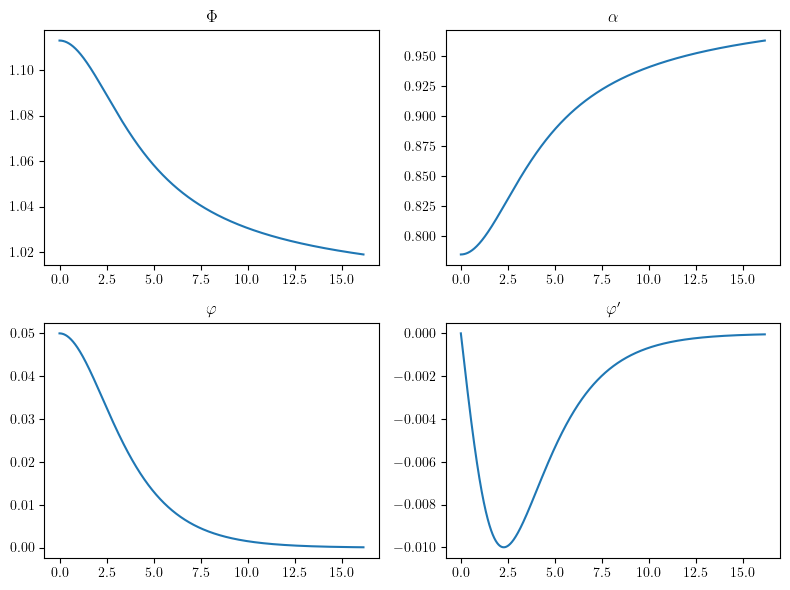

8.768482070128824e-05
0.8952455879715612


In [384]:
r = np.linspace(0, r_max, num_points)
sol2 = solve_bs_iso_rk4(A0,  1.14126807770691130, r_max, num_points, mu)

psi_rescale_factor2 = sol2[0][-1] + r[-1]*sol2[1][-1]
theta_rescale_factor2 = sol2[2][-1] + r[-1]*sol2[3][-1]

eigen_iso = 1.14126807770691130/theta_rescale_factor2*psi_rescale_factor2

sol2[0] = sol2[0]/psi_rescale_factor2
r = r*psi_rescale_factor2**2
sol2[2] = sol2[2]/theta_rescale_factor2
sol2[5] = sol2[5]/psi_rescale_factor2**2

Phi = sol2[0]
Theta = sol2[2]
phi = sol2[4]
phi_prime = sol2[5] 
alpha = Theta/Phi

fig, axes = plt.subplots(2, 2, figsize=(8, 6))  # 2 rows, 2 columns

solution_iso_rk4 = [Phi, alpha, phi, phi_prime]  # replace with your 4 matrices
labels = [r"$\Phi$", r"$\alpha$", r"$\varphi$", r"$\varphi'$"]

for i, (ax, solution, label) in enumerate(zip(axes.flatten(), solution_iso_rk4, labels)):
    ax.plot(r, solution)
    ax.set_title(label)


plt.tight_layout()
plt.show()

print(sol2[4][-1])
print(eigen_iso)

0.6271475464307694


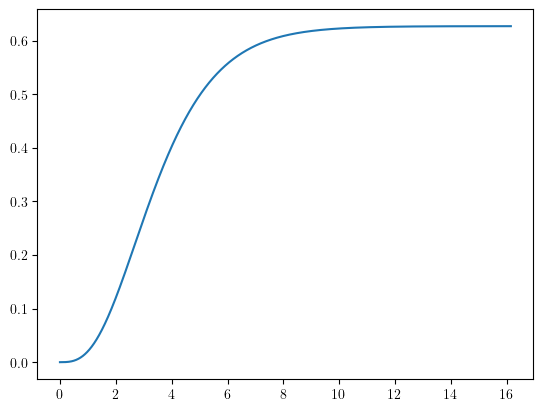

In [385]:
M=np.linspace(0,0,num_points)

for i in range(num_points):
    if i==0:
        M[i]=0
    else:
        dr = r[i] - r[i-1]
        confalpha = alpha[i]/Phi[i]**6

        sig1=eigen_iso*phi[i]**2/confalpha
        M[i] = M[i-1] + (4*pi*r[i]**2*sig1)*dr
        

print(M[-1])
plt.plot(r,M)


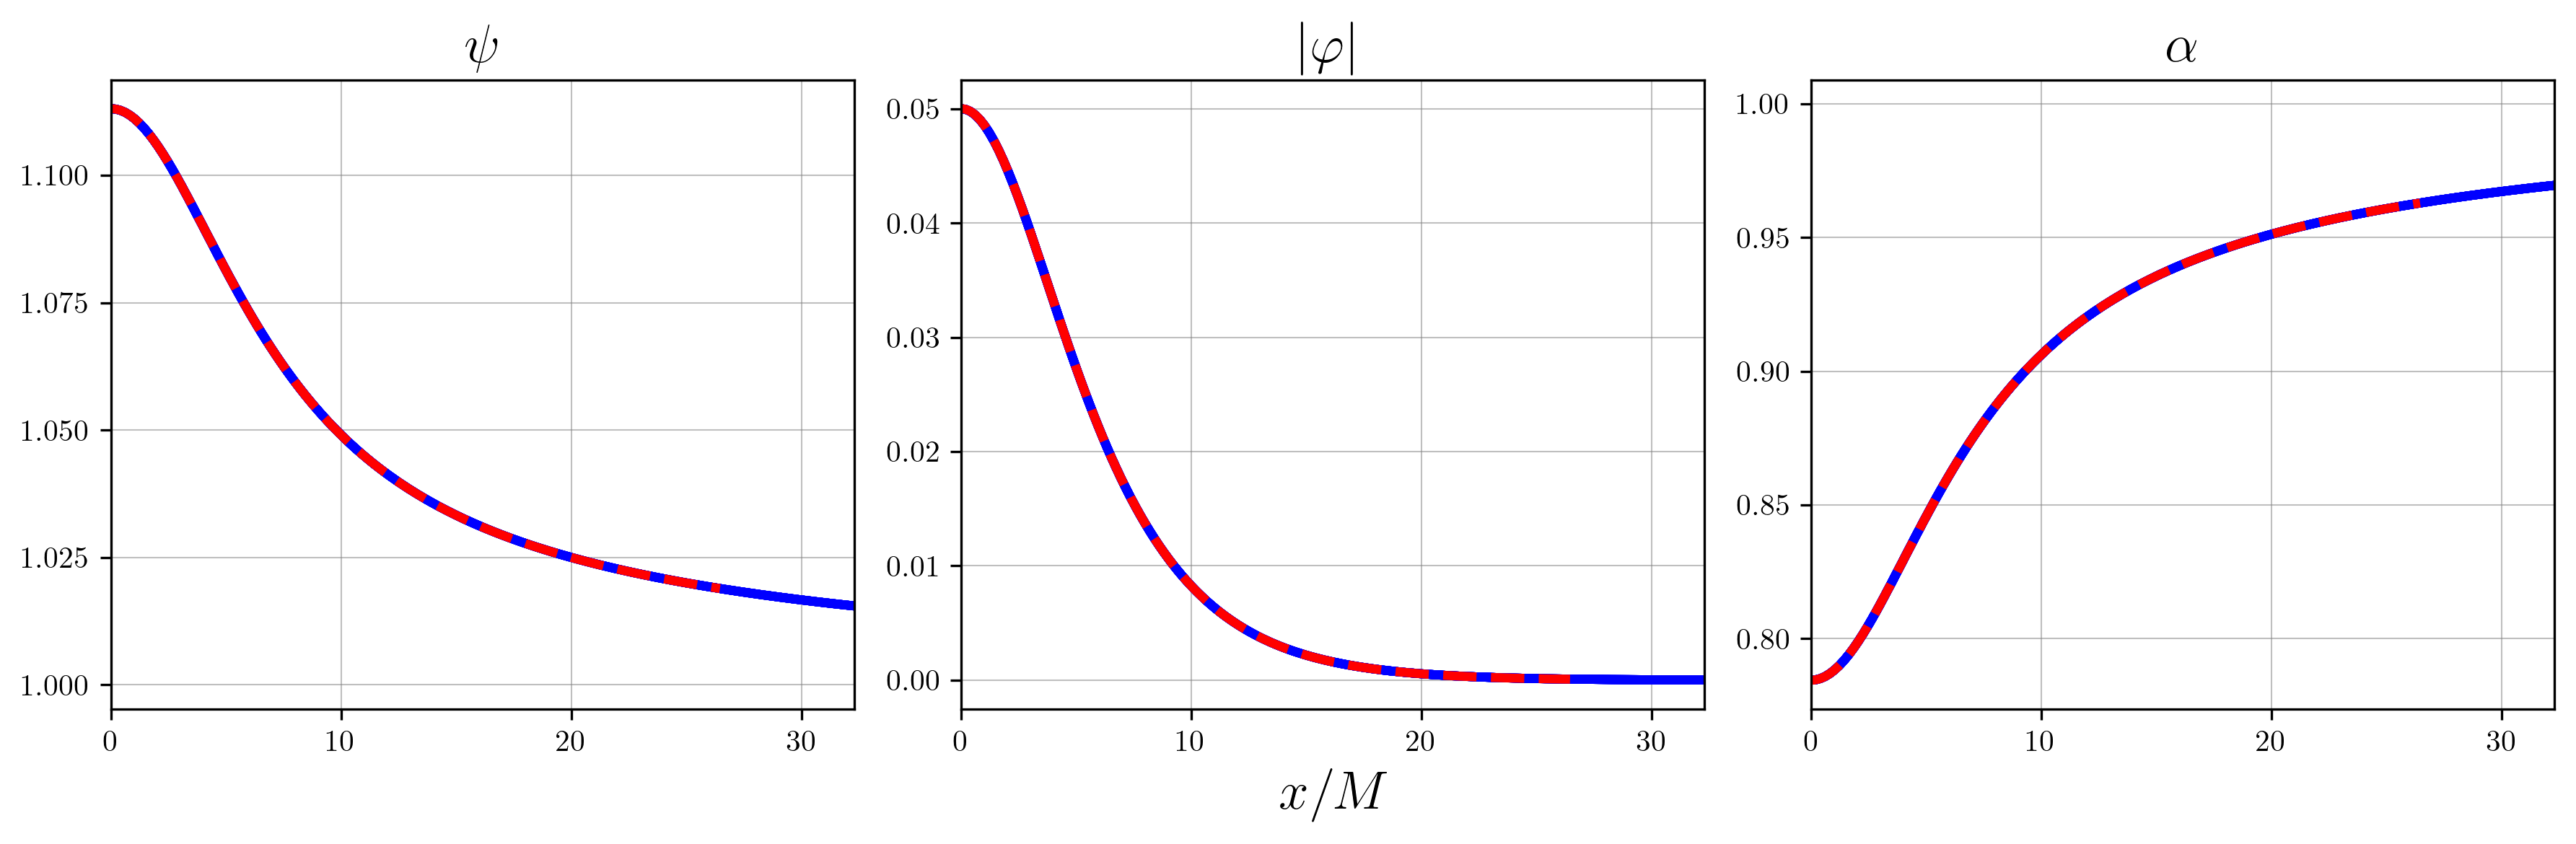

In [387]:
# Define a function to read the file and parse each block into a DataFrame
def read_data_blocks(file_path):
     # Open the file and read its content
    with open(file_path, 'r') as file:
        content = file.read()

    # Split the content by double blank lines
    blocks = content.split('\n\n')

    # Remove any extra blank lines from the blocks
    blocks = [block.strip() for block in blocks if block.strip()]

    # Convert each block to a DataFrame and store them in a list
    data_frames = []
    for block in blocks:
        # Convert block string into a DataFrame
        from io import StringIO
        block_df = pd.read_csv(StringIO(block), sep=r"\s+", header=None)
        data_frames.append(block_df)

    return data_frames

#paths to simulations
path = "../simulations/Mini_Boson_Stars/Stationary_Boson_Star/BS_0.05"

#data
varphi = read_data_blocks(path + "/phiamp.x")
gxx = read_data_blocks(path + "/gxx.x")
lapse = read_data_blocks(path + "/alpha.x")

data0 = [Phi, phi, alpha]  # stationary solution
labels = [r"$\psi$", r"$\left|\varphi\right|$", r"$\alpha$"]

fig, axes = plt.subplots(1, 3, figsize=(12, 4), dpi=300, sharex=True)  # 2 rows, 2 columns
labelsize = 18
ticksize = 16
plt.rcParams['xtick.labelsize'] = ticksize
plt.rcParams['ytick.labelsize'] = ticksize

for i in range(0, len(gxx), round(125*adm)):
    axes[0].plot(gxx[i].iloc[:,0]/adm, gxx[i].iloc[:,1]**0.25, color="blue", linewidth=3) 
    axes[0].set_xlim(r[0], 2*r[-1])

    axes[1].plot(varphi[i].iloc[:,0]/adm, varphi[i].iloc[:,1], color="blue", linewidth=3)

    axes[2].plot(lapse[i].iloc[:,0]/adm, lapse[i].iloc[:,1], color="blue", linewidth=3) 

for i, (ax, solution, label) in enumerate(zip(axes.flatten(), data0, labels)):
    ax.plot(r/adm, solution, linewidth=3, color="red", linestyle='--')
    ax.set_title(label, fontsize=labelsize)
    ax.grid(True, which='major', color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
    if i == 1:
        ax.set_xlabel(r'$x/M$', fontsize=labelsize, fontfamily='times')

plt.tight_layout()
plt.show()

